# MNIST: Sensitivity on $k$ for Log-Linear Model

In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

import warnings
warnings.filterwarnings('ignore')

import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))

import random

import torchvision.datasets as datasets
import torchvision.transforms as transforms

from sklearn.neighbors import KernelDensity

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from PIL import Image

from joblib import Parallel, delayed

from utils import renormalize_image, vectorize_tensor, reconstruct_tensor
import ld

## Setup

### General

In [2]:
def set_random_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    cp.random.seed(seed)

set_random_seed(2)
k = 8
bandwidth = 0.05
eps = np.asarray(1.0e-5)
plot_num = 20
paper_plot_num = 1

### Dataset

In [3]:
D = 28*28
S = (7, 2, 2, 7, 2, 2)
train_size = 100
num_new_samples = 1

In [4]:
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', download=True, train=True, transform=transform)

save_dir = './data/MNIST_images'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    # Save images by class
    for class_label in range(10):
        class_dir = os.path.join(save_dir, str(class_label))
        if not os.path.exists(class_dir):
            os.makedirs(class_dir)

        basis = np.where(train_dataset.targets.numpy() == class_label)[0]
        for i, idx in enumerate(basis):
            img, _ = train_dataset[idx]
            img = transforms.ToPILImage()(img)
            img.save(os.path.join(class_dir, f'{i}.png'))

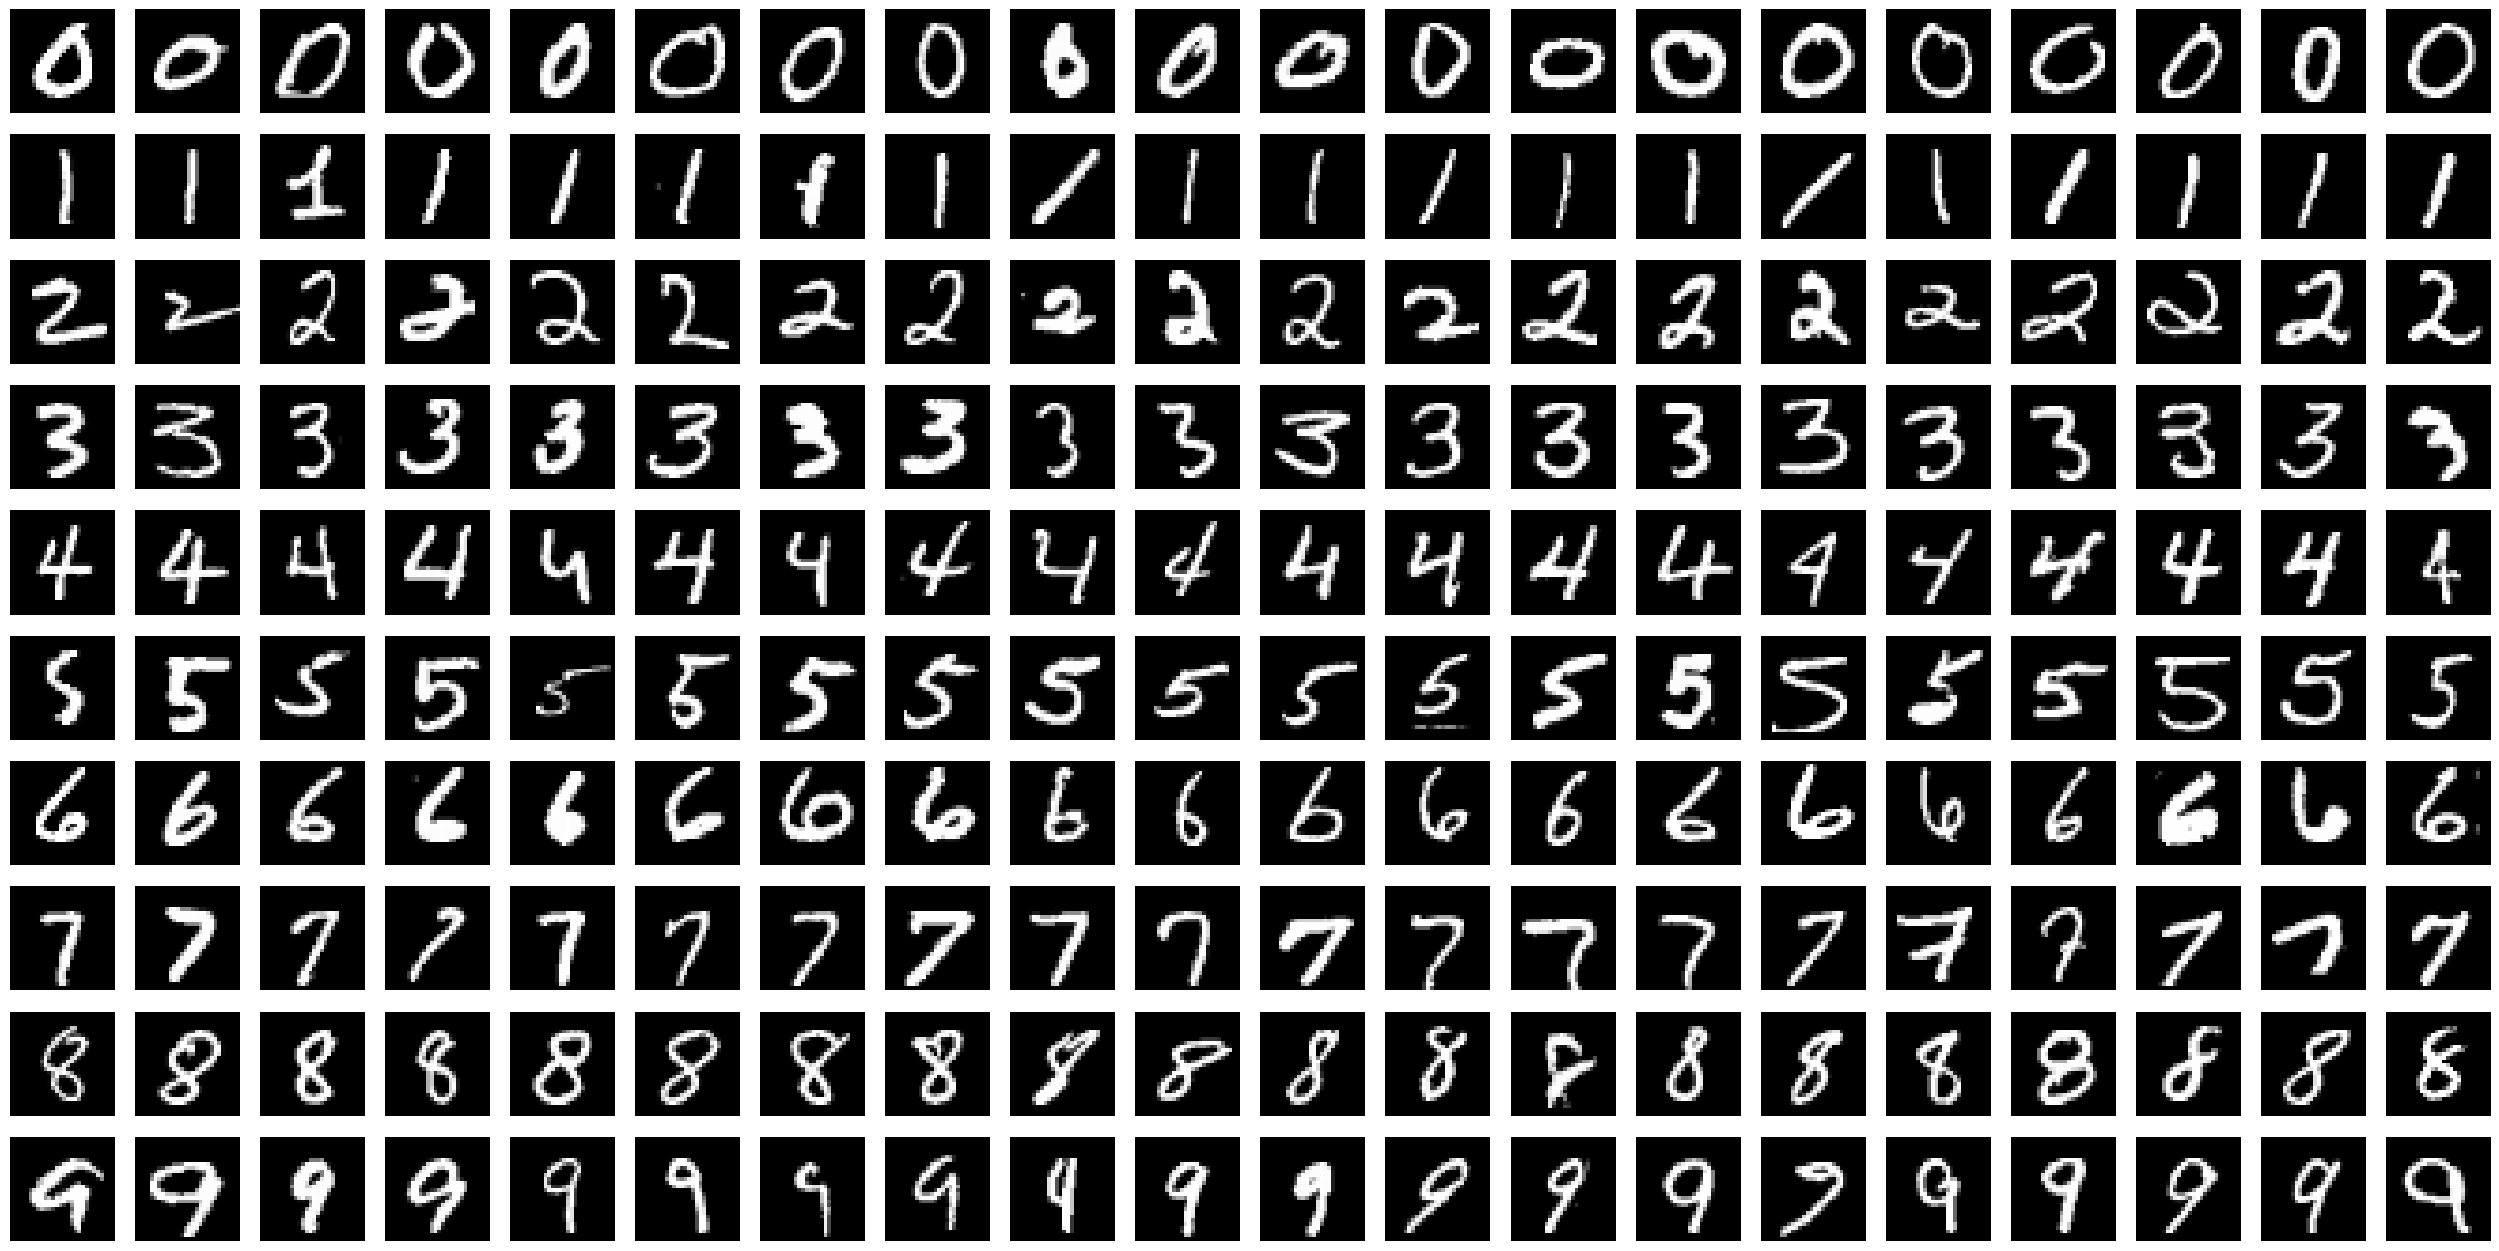

In [5]:
# Function to load images from a directory
def load_images_from_folder(folder, max_images=20):
    images = []
    for filename in os.listdir(folder)[:max_images]:
        img = Image.open(os.path.join(folder, filename))
        if img is not None:
            images.append(img)
    return images

P_digit = []
original_data = []

for digit in range(10):
    class_folder = os.path.join(save_dir, str(digit))
    images = load_images_from_folder(class_folder, max_images=train_size)

    P = []
    for i in range(len(images)):
        img = images[i]
        img = img.resize((28, 28))
        original_data.append(np.asarray(img))
        array_obj = np.asarray(img).reshape(S)
        P.append(array_obj)

    P_digit.append(np.array(P))

# Load and display images horizontally for each class
plt.figure(figsize=(32, 16))
for digit in range(10):
    for i in range(plot_num):
        plt.subplot(10, plot_num, digit * plot_num + i + 1)
        plt.imshow(P_digit[digit][i].reshape((28,28)), cmap='gray', vmin=0, vmax=255)
        plt.axis('off')  # Hide axes

plt.show()

## Data Augmentation with Log-Linear Model

### Legendre Decomposition (Many-Body Approximation)

In [6]:
B_LD = ld.default_B(S, 1, cp.get_array_module(P[0]))

print(B_LD.shape)

def helper(i, digit):
    _, _, scaleX, Q, theta = ld.LD(P_digit[digit][i], B=B_LD, verbose=False, n_iter=1000, lr=1e-1)
    return (scaleX, Q, theta)

results = Parallel(n_jobs=30)(delayed(helper)(i, digit) for i in range(train_size) for digit in range(10))

scaleX_digit = []
Q_digit = []
theta_digit = []
X_recons_digit = []

for digit in range(10):
    scaleX_list = []
    Q_list = []
    theta_list = []
    X_recons_list = []
    for i in range(train_size):
        result = results[i*10 + digit]

        scaleX_list.append(result[0])
        Q_list.append(result[1])
        theta_list.append(result[2])
        X_recons = (result[1] * result[0]).astype(np.int32)
        X_recons_list.append(X_recons)

    scaleX_digit.append(np.array(scaleX_list))
    Q_digit.append(np.array(Q_list))
    theta_digit.append(np.array(theta_list))
    X_recons_digit.append(np.array(X_recons_list))

(17, 6)


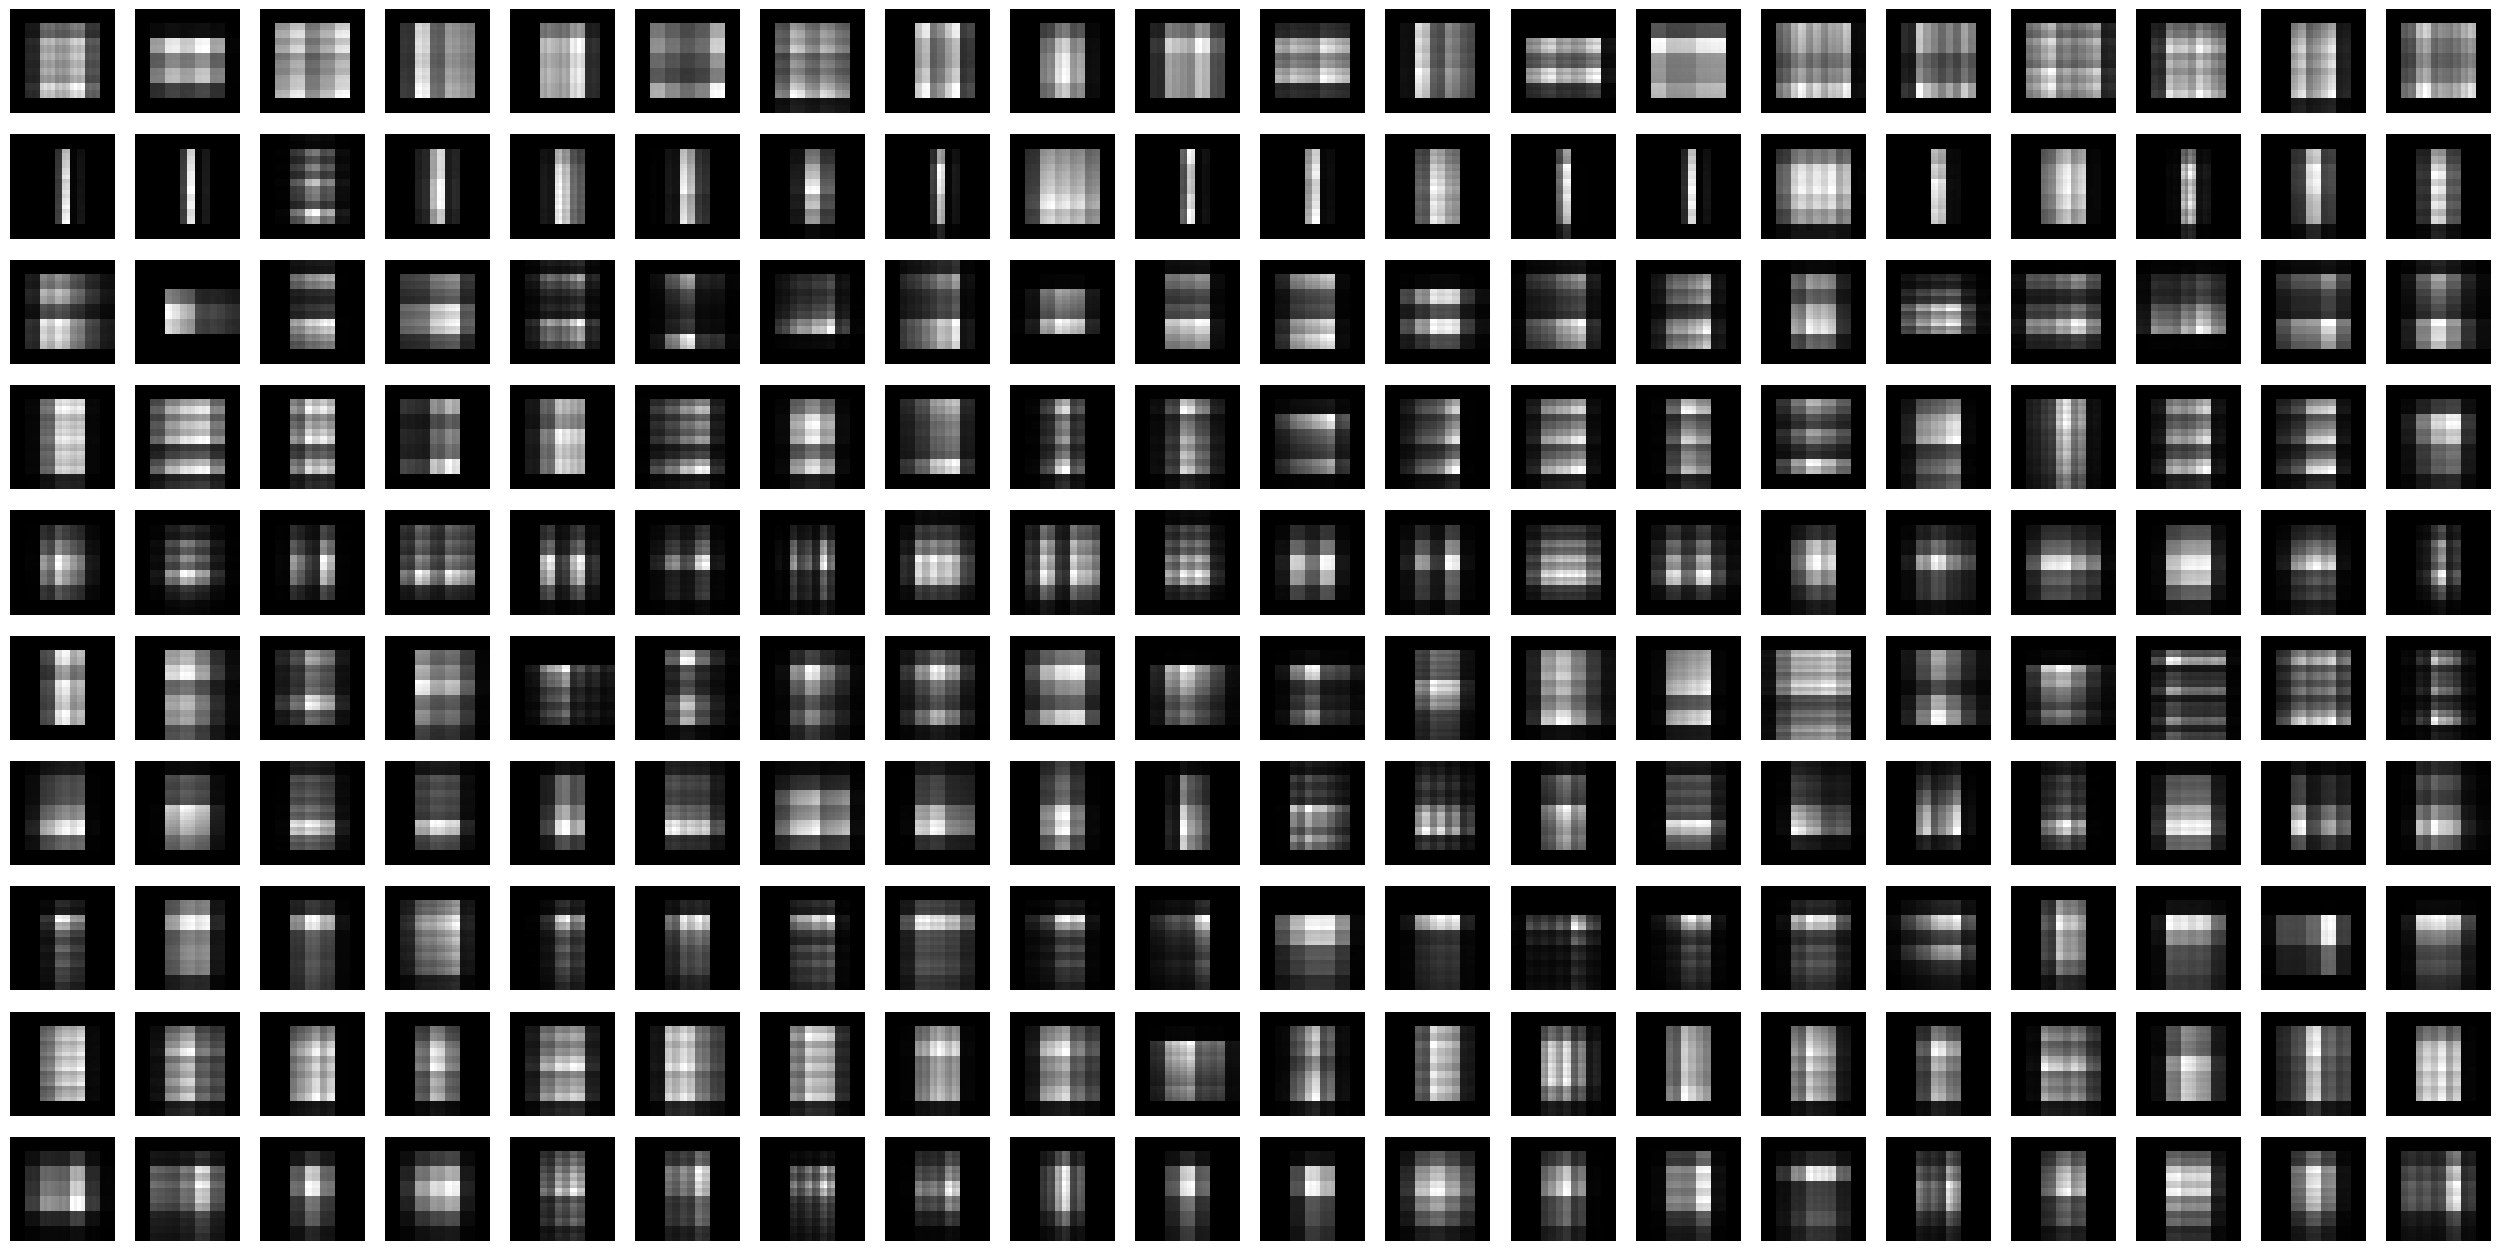

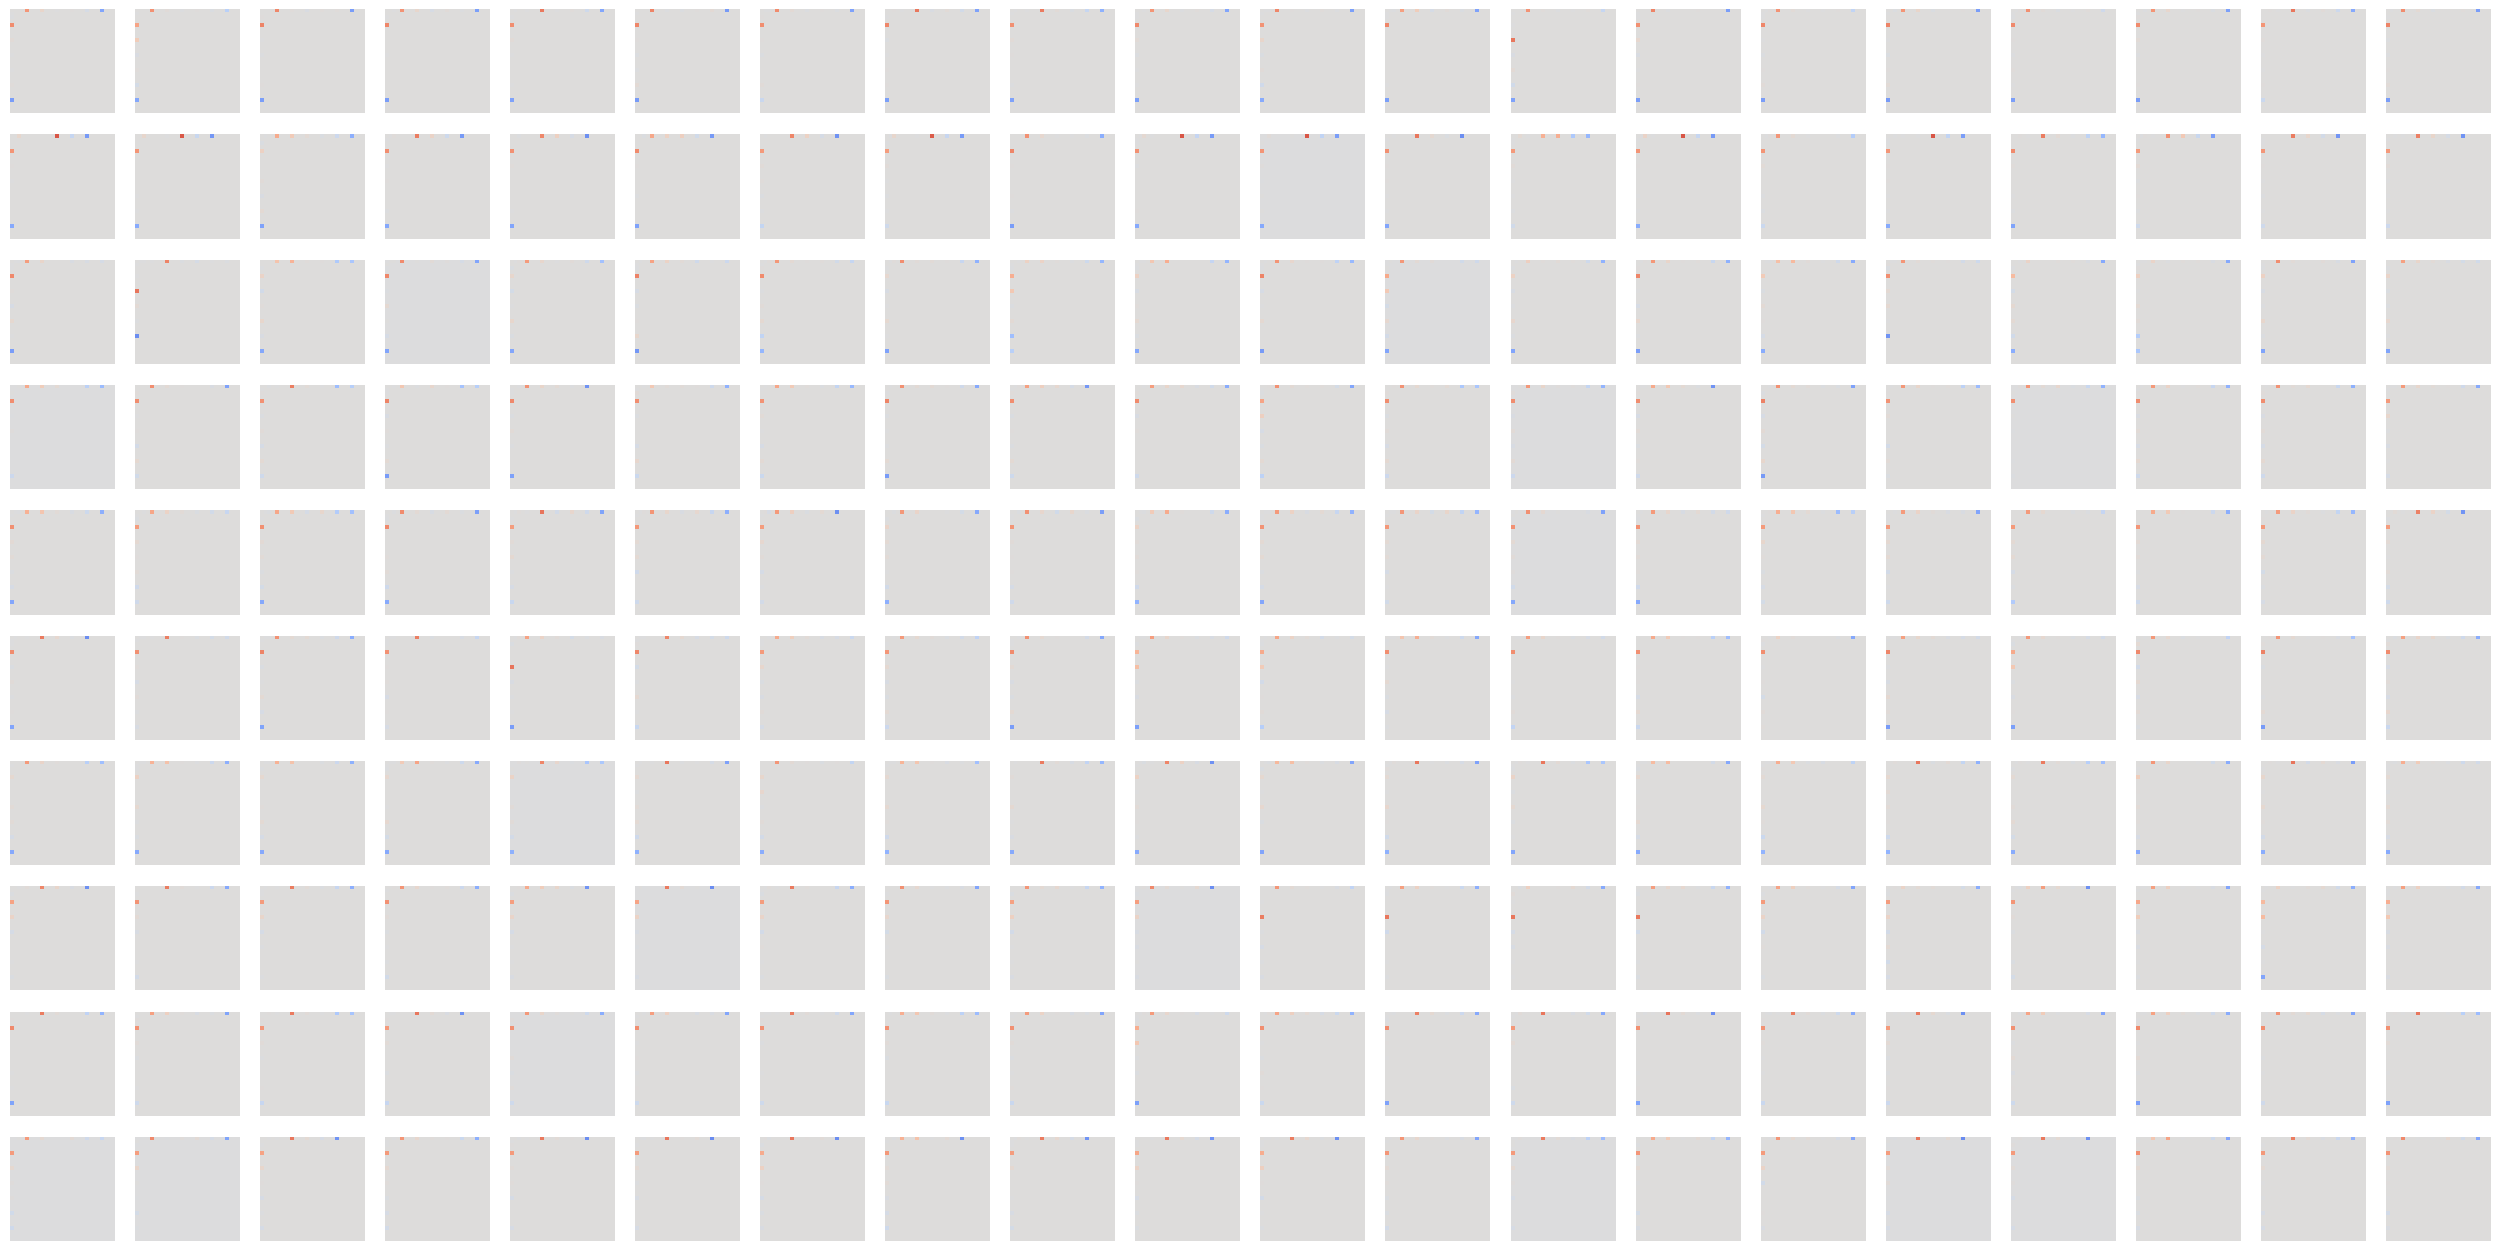

In [7]:
# Load and display images horizontally for each class
plt.figure(figsize=(32, 16))
for digit in range(10):
    for i in range(plot_num):
        plt.subplot(10, plot_num, digit * plot_num + i + 1)
        plt.imshow(renormalize_image(X_recons_digit[digit][i]).reshape((28, 28)), cmap='gray', vmin=0, vmax=255)
        plt.axis('off')  # Hide axes

plt.show()

plt.figure(figsize=(32, 16))
for digit in range(10):
    for i in range(plot_num):
        plt.subplot(10, plot_num, digit * plot_num + i + 1)
        plt.imshow(theta_digit[digit][i].reshape((28, 28)), cmap='coolwarm', vmin=-15, vmax=15)
        plt.axis('off')  # Hide axes

plt.show()

#### Fitting on Projected Points

In [8]:
sampled_theta_digit = []

for digit in range(10):
    reduced_theta = vectorize_tensor(theta_digit[digit], B_LD)

    # Fit a KDE to the theta values
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(reduced_theta)
    # Sample new data from the KDE
    sampled_reduced_theta = kde.sample(n_samples=num_new_samples)

    sampled_theta = reconstruct_tensor(sampled_reduced_theta, (num_new_samples, *S), B_LD)
    sampled_theta_digit.append(sampled_theta)

# plt.figure(figsize=(32, 16))
# for digit in range(10):
#     for i in range(plot_num):
#         plt.subplot(10, plot_num, digit * plot_num + i + 1)
#         plt.imshow(sampled_theta_digit[digit][i].reshape((28, 28)), cmap='coolwarm', vmin=-15, vmax=15)
#         plt.axis('off')  # Hide axes

# plt.show()

#### Construct Local-Data Sub-Manifold

In [9]:
# Construct the constrained coordinates
# B_BP = ld.block_B([14, 14], [15, 15])
B_BP = ld.default_B(S, 1, cp.get_array_module(P[0]))

# Compute every datapoint's eta_hat (served as the linear constraints)
eta_hat_digit = []

for digit in range(10):
    eta_hat_list = []
    for i in range(P_digit[digit].shape[0]):
        xp = cp.get_array_module(P_digit[digit][i])
        P = (P_digit[digit][i] + eps) / scaleX_digit[digit][i]
        eta_hat = ld.get_eta(P, len(S), xp)
        eta_hat_list.append(eta_hat)

    eta_hat_digit.append(cp.asarray(eta_hat_list))

#### Backward Projection with different $k$

k = 1


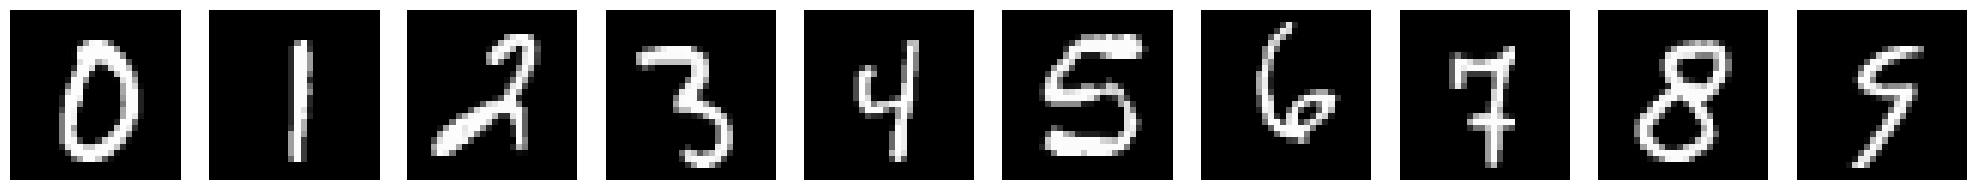

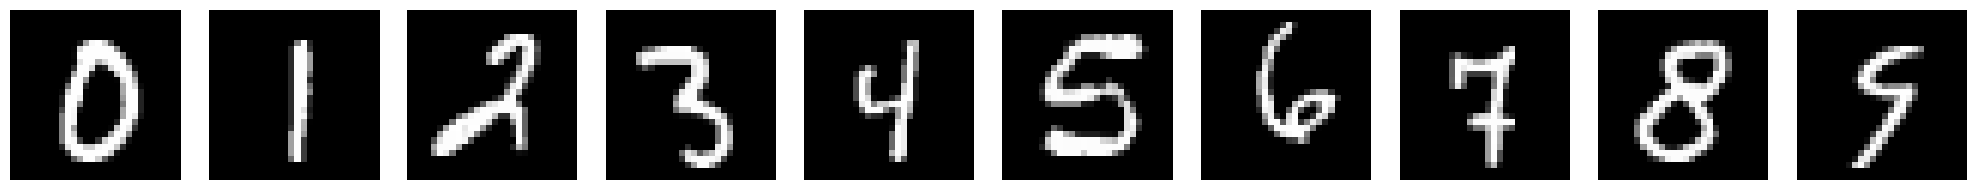

k = 4


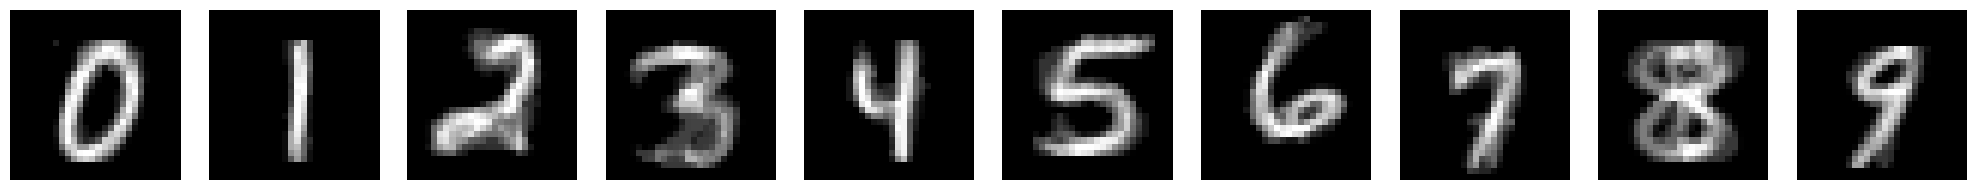

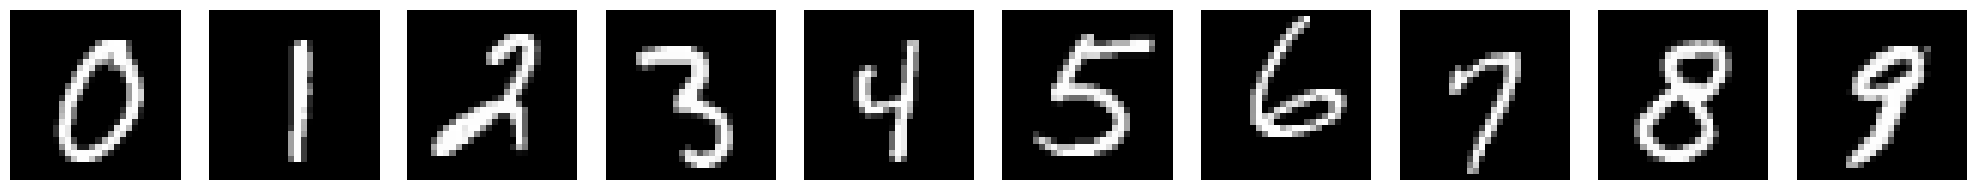

k = 8


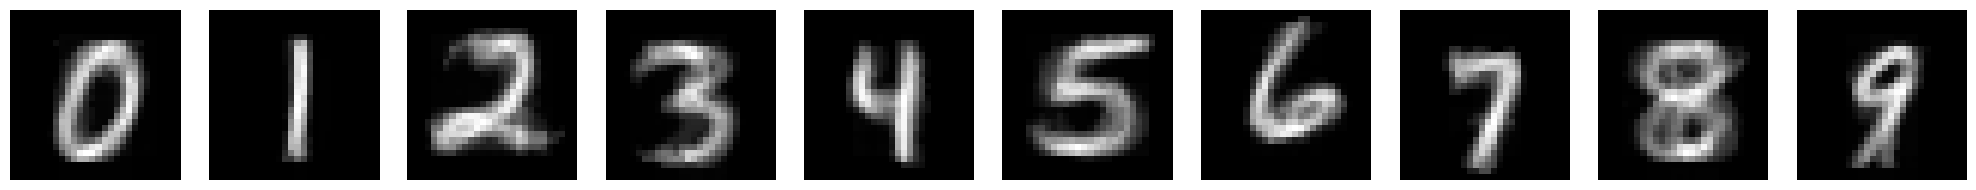

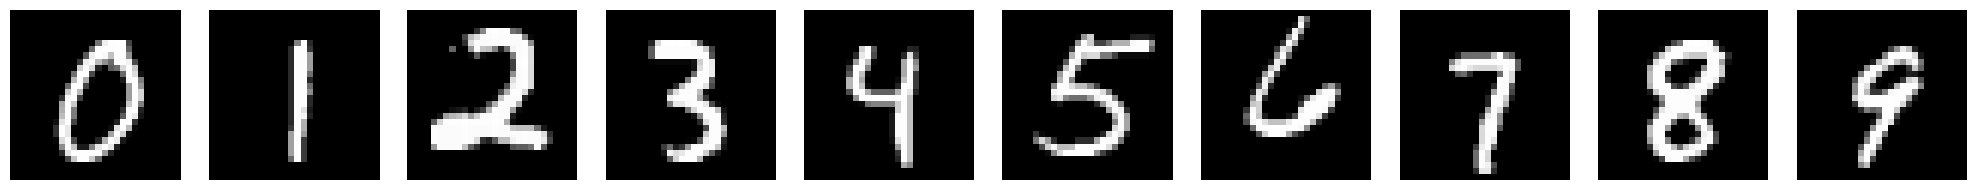

k = 16


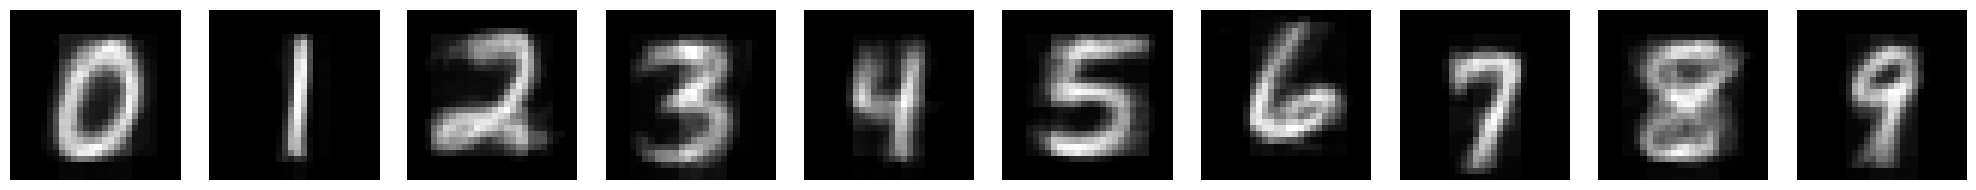

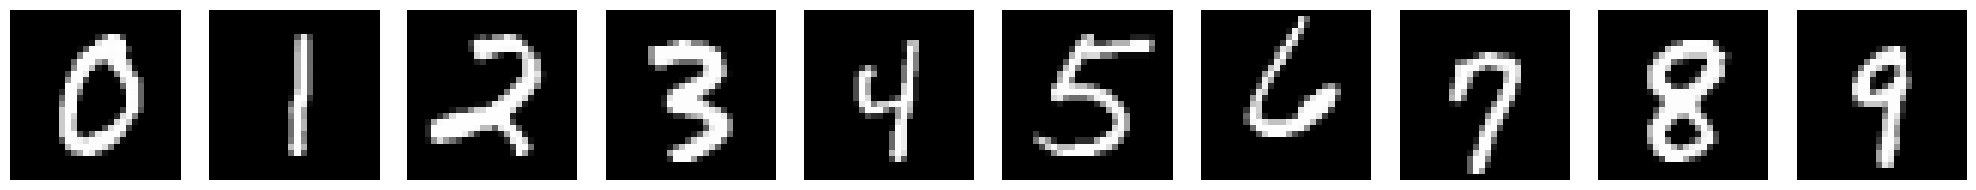

In [10]:
for k in [1, 4, 8, 16]:
    print(f'k = {k}')

    def helper2(i, digit):
        N = ld.kNN(sampled_theta_digit[digit][i], theta_digit[digit], k=k)
        avg_scale = np.mean(scaleX_digit[digit][N])
        avg_eta_hat = np.mean(eta_hat_digit[digit][N], axis=0)
        _, _, P, theta = ld.BP(sampled_theta_digit[digit][i], [(P_digit[digit][j] + eps) / scaleX_digit[digit][j] for j in N], avg_eta_hat, avg_scale, B=B_BP, verbose=False, n_iter=1000, lr=1e-1)
        X_recons_ = (P).astype(np.int32).reshape(-1)
        return (P, theta, X_recons_)

    results = Parallel(n_jobs=30)(delayed(helper2)(i, digit) for i in range(num_new_samples) for digit in range(10))

    sampled_P_BP_digit = []
    sampled_theta_BP_digit = []
    sampled_X_recons_digit = []

    for digit in range(10):
        sampled_P_BP = []
        sampled_theta_BP = []
        sampled_X_recons = []
        for i in range(num_new_samples):
            result = results[i*10 + digit]

            sampled_P_BP.append(result[0])
            sampled_theta_BP.append(result[1])
            sampled_X_recons.append(result[2])

        sampled_P_BP_digit.append(np.array(sampled_P_BP))
        sampled_theta_BP_digit.append(np.array(sampled_theta_BP))
        sampled_X_recons_digit.append(np.array(sampled_X_recons))

    # plt.figure(figsize=(32, 16))
    # for digit in range(10):
    #     for i in range(plot_num):
    #         plt.subplot(10, plot_num, digit * plot_num + i + 1)
    #         plt.imshow(renormalize_image(sampled_X_recons_digit[digit][i]).reshape((28, 28)), cmap='gray', vmin=0, vmax=255)
    #         plt.axis('off')  # Hide axes

    # plt.show()

    # # Find the nearest distance between every new sample among the training set in terms of norm.
    # plt.figure(figsize=(32, 16))
    # for digit in range(10):
    #     for i in range(plot_num):
    #         norm = [np.linalg.norm(sampled_X_recons_digit[digit][i].reshape((28, 28)) - p.reshape((28, 28))) for p in P_digit[digit]]
    #         idx = np.argmin(norm)
    #         plt.subplot(10, plot_num, digit * plot_num + i + 1)
    #         plt.imshow(P_digit[digit][idx].reshape((28, 28)), cmap='gray', vmin=0, vmax=255) # [0, 255]
    #         plt.axis('off')  # Hide axes

    # plt.show()

    plt.figure(figsize=(20, 2))
    for digit in range(10):
        for i in range(paper_plot_num):
            plt.subplot(paper_plot_num, 10, digit * paper_plot_num + i + 1)
            plt.imshow(renormalize_image(sampled_X_recons_digit[digit][i]).reshape((28, 28)), cmap='gray', vmin=0, vmax=255)
            plt.axis('off')  # Hide axes

    plt.tight_layout()

    plt.savefig(f'../Figures/MNIST/extra_k/BP_k={k}.pdf', format='pdf')

    plt.show()

    # Find the nearest distance between every new sample among the training set in terms of norm.
    plt.figure(figsize=(20, 2))
    for digit in range(10):
        for i in range(paper_plot_num):
            norm = [np.linalg.norm(sampled_X_recons_digit[digit][i].reshape((28, 28)) - p.reshape((28, 28))) for p in P_digit[digit]]
            idx = np.argmin(norm)
            plt.subplot(paper_plot_num, 10, digit * paper_plot_num + i + 1)
            plt.imshow(P_digit[digit][idx].reshape((28, 28)), cmap='gray', vmin=0, vmax=255) # [0, 255]
            plt.axis('off')  # Hide axes

    plt.tight_layout()

    plt.savefig(f'../Figures/MNIST/extra_k/BP_k={k}_compare.pdf', format='pdf')

    plt.show()